0.
Задача классификации: анализ личности клиента для прогнозирования принятия маркетинговых предложений

Целевая переменная: Response (принял ли клиент предложение в последней кампании - 1: да, 0: нет)

Цель - построить модель, которая сможет предсказать, примет ли клиент маркетинговое предложение.

1. Чтение данных

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn
%matplotlib inline

url = 'https://raw.githubusercontent.com/kintoqq/machine_learning/refs/heads/main/marketing_campaign.csv'
data = pd.read_csv(url, sep='\t', header=0,  engine='python')

data['Education'] = data['Education'].astype('category')
data['Marital_Status'] = data['Marital_Status'].astype('category')

data.isnull().sum()



,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


Предобработка данных


In [3]:
income_median = data['Income'].median()
data_clean = data.copy()
data_clean['Income'] = data_clean['Income'].fillna(income_median)

data_clean['Age'] = 2025 - data_clean['Year_Birth']

data_clean['TotalSpent'] = data_clean[['MntWines', 'MntFruits', 'MntMeatProducts',
                                     'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)

data_clean['NumTotalPurchases'] = data_clean[['NumWebPurchases', 'NumCatalogPurchases',
                                            'NumStorePurchases', 'NumDealsPurchases']].sum(axis=1)

data_clean['Children'] = data_clean['Kidhome'] + data_clean['Teenhome']

data_clean['CustomerSeniority'] = 2023 - pd.to_datetime(data_clean['Dt_Customer'], dayfirst=True).dt.year

cols_to_drop = ['ID', 'Year_Birth', 'Dt_Customer', 'Z_CostContact', 'Z_Revenue','MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumDealsPurchases',
    'Kidhome', 'Teenhome']
data_clean = data_clean.drop([col for col in cols_to_drop if col in data_clean.columns], axis=1)

print(f"Новый размер данных: {data_clean.shape}")
print("\nОставшиеся признаки:")
print(data_clean.columns.tolist())
data_clean.head()

Новый размер данных: (2240, 17)

Оставшиеся признаки:
['Education', 'Marital_Status', 'Income', 'Recency', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response', 'Age', 'TotalSpent', 'NumTotalPurchases', 'Children', 'CustomerSeniority']


,Education,Marital_Status,Income,Recency,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,TotalSpent,NumTotalPurchases,Children,CustomerSeniority
0,Graduation,Single,58138.0,58,7,0,0,0,0,0,0,1,68,1617,25,0,11
1,Graduation,Single,46344.0,38,5,0,0,0,0,0,0,0,71,27,6,2,9
2,Graduation,Together,71613.0,26,4,0,0,0,0,0,0,0,60,776,21,0,10
3,Graduation,Together,26646.0,26,6,0,0,0,0,0,0,0,41,53,8,1,9
4,PhD,Married,58293.0,94,5,0,0,0,0,0,0,0,44,422,19,1,9


In [4]:
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Education          2240 non-null   category
 1   Marital_Status     2240 non-null   category
 2   Income             2240 non-null   float64 
 3   Recency            2240 non-null   int64   
 4   NumWebVisitsMonth  2240 non-null   int64   
 5   AcceptedCmp3       2240 non-null   int64   
 6   AcceptedCmp4       2240 non-null   int64   
 7   AcceptedCmp5       2240 non-null   int64   
 8   AcceptedCmp1       2240 non-null   int64   
 9   AcceptedCmp2       2240 non-null   int64   
 10  Complain           2240 non-null   int64   
 11  Response           2240 non-null   int64   
 12  Age                2240 non-null   int64   
 13  TotalSpent         2240 non-null   int64   
 14  NumTotalPurchases  2240 non-null   int64   
 15  Children           2240 non-null   int64   
 16  Custom

2. Обучающая и тестовая выборки

In [5]:
X = data_clean.drop(['Response'], axis=1)
y = data_clean['Response']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

N_train, _ = X_train.shape
N_test,  _ = X_test.shape

N_train, N_test

(1680, 560)

3. Визуализацияя и основные характеристики

In [6]:
# числовые признаки
numeric_features = data_clean.select_dtypes(include=[np.number]).columns
print("Числовые признаки:", len(numeric_features))

# категориальнык признаки
categorical_features = data_clean.select_dtypes(include=['category']).columns
print("Категориальные признаки:", len(categorical_features))
print("Категориальные признаки:", list(categorical_features))

Числовые признаки: 15
Категориальные признаки: 2
Категориальные признаки: ['Education', 'Marital_Status']


In [7]:
for feature in categorical_features:
    print(f"\n{feature}:")
    print(data_clean[feature].value_counts())
    print(f"Категории: {list(data_clean[feature].cat.categories)}")


Education:
Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64
Категории: ['2n Cycle', 'Basic', 'Graduation', 'Master', 'PhD']

Marital_Status:
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64
Категории: ['Absurd', 'Alone', 'Divorced', 'Married', 'Single', 'Together', 'Widow', 'YOLO']


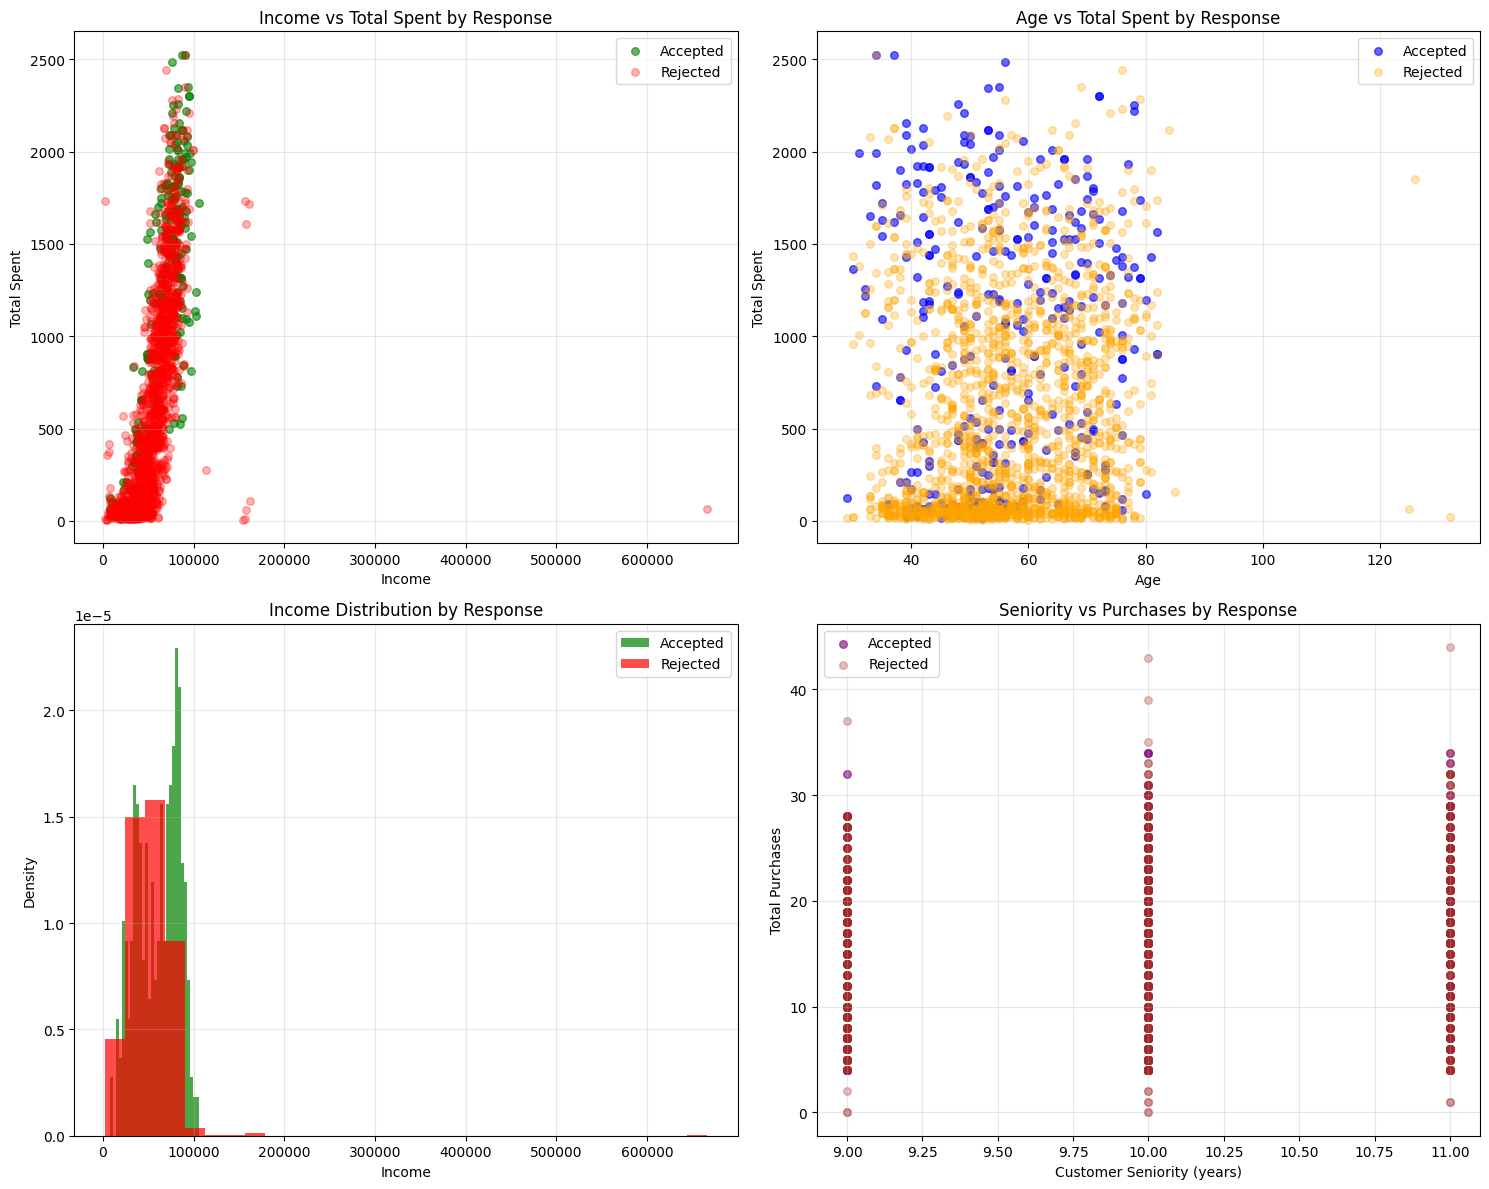

In [8]:
plt.figure(figsize=(15, 12))

plt.subplot(2, 2, 1)
accepted = data_clean[data_clean['Response'] == 1]
rejected = data_clean[data_clean['Response'] == 0]

plt.scatter(accepted['Income'], accepted['TotalSpent'],
           alpha=0.6, color='green', label='Accepted', s=30)
plt.scatter(rejected['Income'], rejected['TotalSpent'],
           alpha=0.3, color='red', label='Rejected', s=30)
plt.xlabel('Income')
plt.ylabel('Total Spent')
plt.title('Income vs Total Spent by Response')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.scatter(accepted['Age'], accepted['TotalSpent'],
           alpha=0.6, color='blue', label='Accepted', s=30)
plt.scatter(rejected['Age'], rejected['TotalSpent'],
           alpha=0.3, color='orange', label='Rejected', s=30)
plt.xlabel('Age')
plt.ylabel('Total Spent')
plt.title('Age vs Total Spent by Response')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
plt.hist(accepted['Income'], bins=30, alpha=0.7, color='green',
         label='Accepted', density=True)
plt.hist(rejected['Income'], bins=30, alpha=0.7, color='red',
         label='Rejected', density=True)
plt.xlabel('Income')
plt.ylabel('Density')
plt.title('Income Distribution by Response')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
plt.scatter(accepted['CustomerSeniority'], accepted['NumTotalPurchases'],
           alpha=0.6, color='purple', label='Accepted', s=30)
plt.scatter(rejected['CustomerSeniority'], rejected['NumTotalPurchases'],
           alpha=0.3, color='brown', label='Rejected', s=30)
plt.xlabel('Customer Seniority (years)')
plt.ylabel('Total Purchases')
plt.title('Seniority vs Purchases by Response')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Можно заметить выбросы в доходе и возрасте, нужно это исправить

In [9]:
data_clean.quantile([0.005,.01,.05,.1,.5,.9,.95,.99,.995], numeric_only=True)

,Income,Recency,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,TotalSpent,NumTotalPurchases,Children,CustomerSeniority
0.005,7500.00,0.0,1.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,32.000,10.00,4.0,0.0,9.0
0.010,7705.92,0.0,1.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33.000,13.00,4.0,0.0,9.0
0.050,19101.05,4.0,1.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,37.000,22.00,4.0,0.0,9.0
0.100,24219.50,9.0,2.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,41.000,34.90,5.0,0.0,9.0
0.500,51381.50,49.0,6.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,55.000,396.00,15.0,1.0,10.0
0.900,79800.30,89.0,8.000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,73.000,1536.20,25.0,2.0,11.0
0.950,83927.00,94.0,8.000,1.0,1.0,1.0,1.0,0.0,0.0,1.0,75.000,1772.30,27.0,2.0,11.0
0.990,94437.68,98.0,9.000,1.0,1.0,1.0,1.0,1.0,0.0,1.0,80.000,2126.00,32.0,3.0,11.0
0.995,102122.95,99.0,9.805,1.0,1.0,1.0,1.0,1.0,1.0,1.0,81.805,2274.71,33.0,3.0,11.0


In [10]:
rows_to_drop = data_clean[
    (data_clean['Income'] < data_clean['Income'].quantile(0.005)) | (data_clean['Income'] > data_clean['Income'].quantile(0.995)) |
    (data_clean['Age'] < data_clean['Age'].quantile(0.005)) | (data_clean['Age'] > data_clean['Age'].quantile(0.995))].index
data_clean = data_clean.drop(rows_to_drop)
data_clean.describe()

,Income,Recency,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,TotalSpent,NumTotalPurchases,Children,CustomerSeniority
count,2195.000000,2195.000000,2195.000000,2195.000000,2195.000000,2195.000000,2195.000000,2195.000000,2195.000000,2195.000000,2195.000000,2195.000000,2195.000000,2195.000000,2195.000000
mean,51676.941458,49.125285,5.313895,0.071982,0.074715,0.069704,0.063781,0.012756,0.008200,0.148064,56.113895,602.905239,14.834624,0.961731,9.974032
std,20215.028550,28.986500,2.297865,0.258517,0.262991,0.254705,0.244419,0.112247,0.090205,0.355244,11.511508,599.384250,7.555838,0.749593,0.684348
min,7500.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,32.000000,8.000000,1.000000,0.000000,9.000000
25%,35686.000000,24.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,48.000000,69.000000,8.000000,0.000000,10.000000
50%,51381.500000,49.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,55.000000,396.000000,15.000000,1.000000,10.000000
75%,67902.000000,74.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,66.000000,1038.500000,21.000000,1.000000,10.000000
max,101970.000000,99.000000,19.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,81.000000,2525.000000,39.000000,3.000000,11.000000


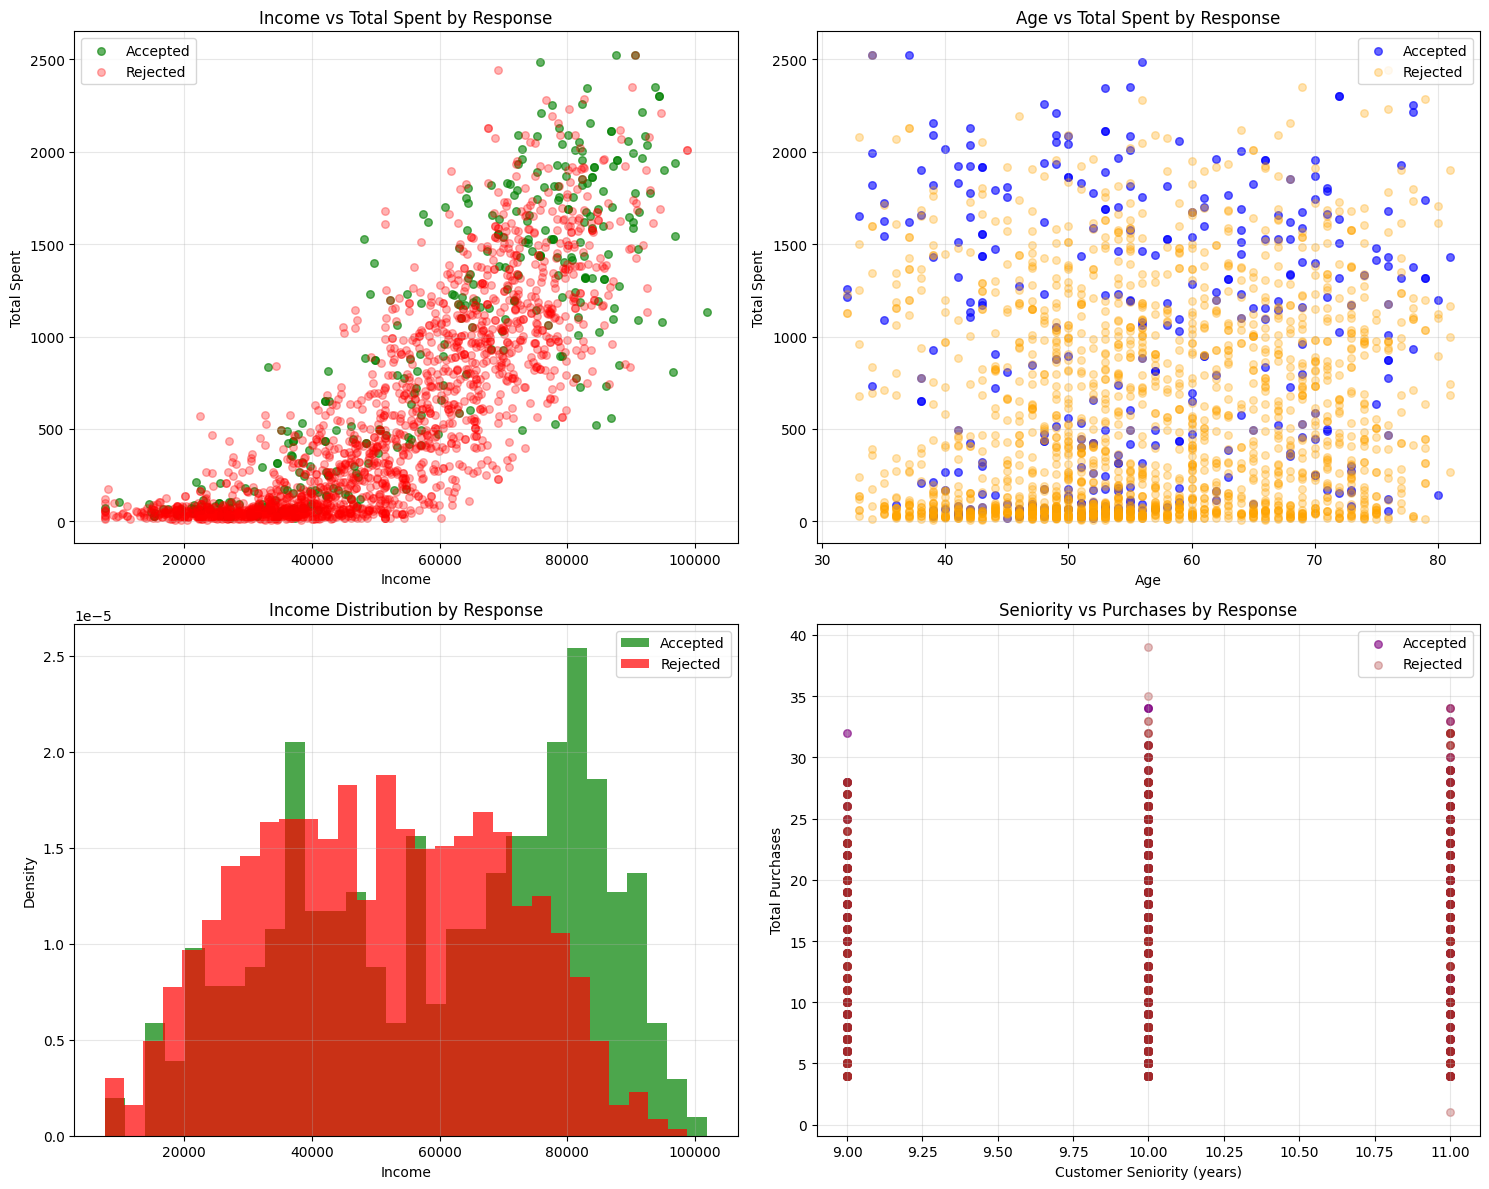

In [11]:
plt.figure(figsize=(15, 12))

plt.subplot(2, 2, 1)
accepted = data_clean[data_clean['Response'] == 1]
rejected = data_clean[data_clean['Response'] == 0]

plt.scatter(accepted['Income'], accepted['TotalSpent'],
           alpha=0.6, color='green', label='Accepted', s=30)
plt.scatter(rejected['Income'], rejected['TotalSpent'],
           alpha=0.3, color='red', label='Rejected', s=30)
plt.xlabel('Income')
plt.ylabel('Total Spent')
plt.title('Income vs Total Spent by Response')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.scatter(accepted['Age'], accepted['TotalSpent'],
           alpha=0.6, color='blue', label='Accepted', s=30)
plt.scatter(rejected['Age'], rejected['TotalSpent'],
           alpha=0.3, color='orange', label='Rejected', s=30)
plt.xlabel('Age')
plt.ylabel('Total Spent')
plt.title('Age vs Total Spent by Response')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
plt.hist(accepted['Income'], bins=30, alpha=0.7, color='green',
         label='Accepted', density=True)
plt.hist(rejected['Income'], bins=30, alpha=0.7, color='red',
         label='Rejected', density=True)
plt.xlabel('Income')
plt.ylabel('Density')
plt.title('Income Distribution by Response')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
plt.scatter(accepted['CustomerSeniority'], accepted['NumTotalPurchases'],
           alpha=0.6, color='purple', label='Accepted', s=30)
plt.scatter(rejected['CustomerSeniority'], rejected['NumTotalPurchases'],
           alpha=0.3, color='brown', label='Rejected', s=30)
plt.xlabel('Customer Seniority (years)')
plt.ylabel('Total Purchases')
plt.title('Seniority vs Purchases by Response')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

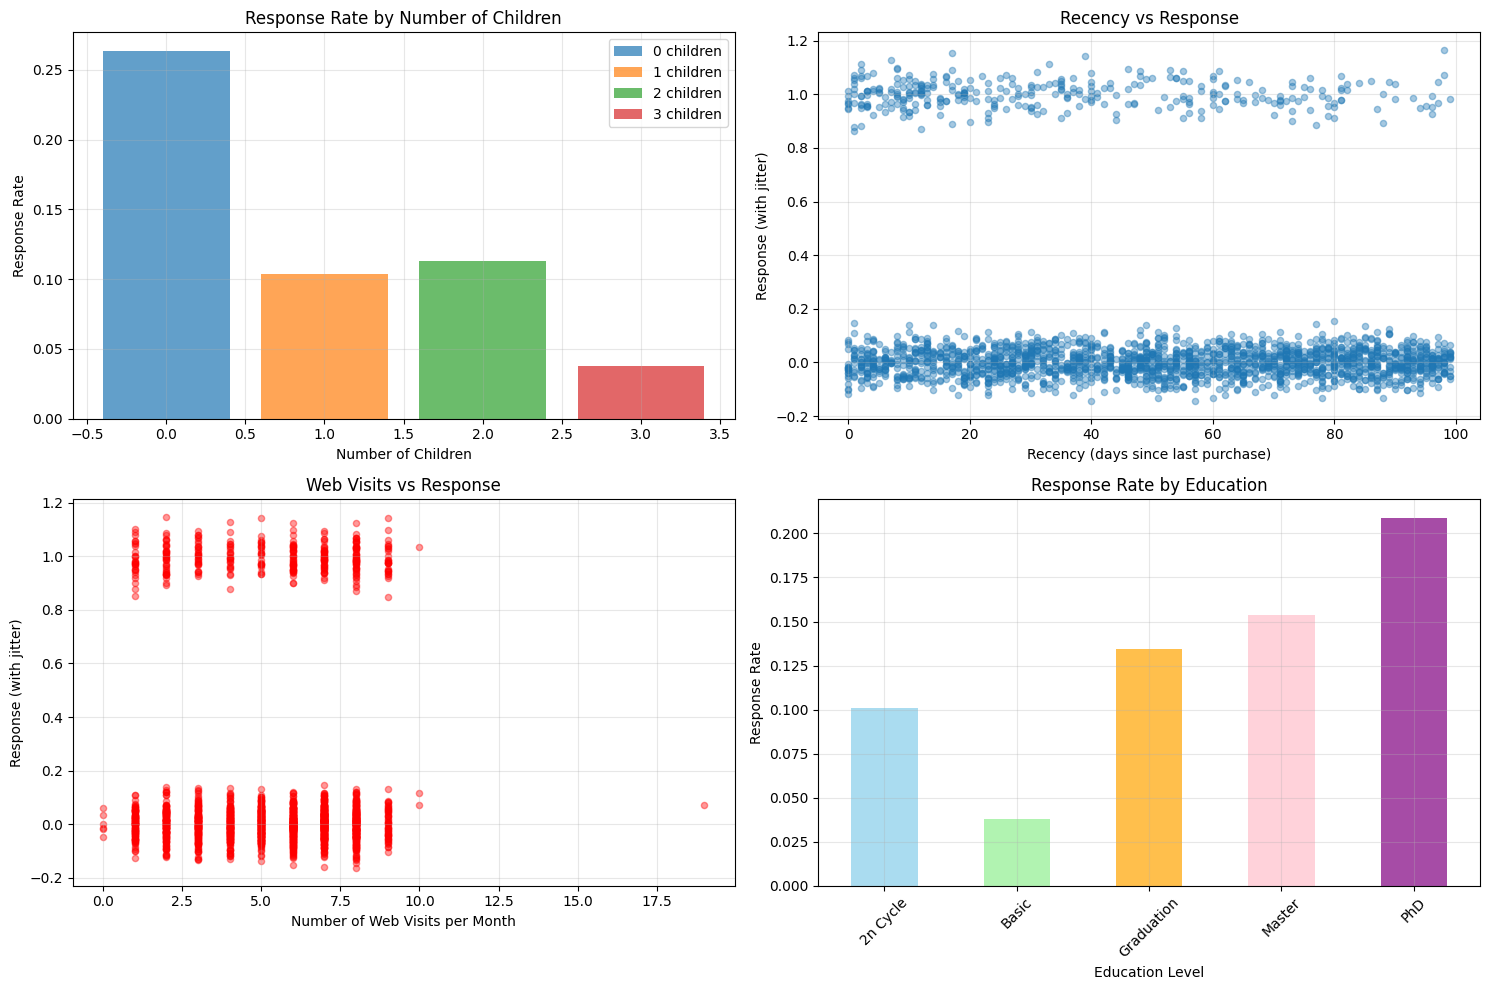

In [12]:
plt.figure(figsize=(15, 10))

# 1. Анализ Children vs Response
plt.subplot(2, 2, 1)
for children_count in sorted(data_clean['Children'].unique()):
    subset = data_clean[data_clean['Children'] == children_count]
    response_rate = subset['Response'].mean()
    plt.bar(children_count, response_rate, alpha=0.7,
            label=f'{children_count} children')
plt.xlabel('Number of Children')
plt.ylabel('Response Rate')
plt.title('Response Rate by Number of Children')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Recency vs Response
plt.subplot(2, 2, 2)
plt.scatter(data_clean['Recency'], data_clean['Response'] + np.random.normal(0, 0.05, len(data_clean)),
           alpha=0.4, s=20)
plt.xlabel('Recency (days since last purchase)')
plt.ylabel('Response (with jitter)')
plt.title('Recency vs Response')
plt.grid(True, alpha=0.3)

# 3. NumWebVisitsMonth vs Response
plt.subplot(2, 2, 3)
plt.scatter(data_clean['NumWebVisitsMonth'], data_clean['Response'] + np.random.normal(0, 0.05, len(data_clean)),
           alpha=0.4, s=20, color='red')
plt.xlabel('Number of Web Visits per Month')
plt.ylabel('Response (with jitter)')
plt.title('Web Visits vs Response')
plt.grid(True, alpha=0.3)

# 4. Анализ по Education
plt.subplot(2, 2, 4)
education_response = data_clean.groupby('Education')['Response'].mean()
education_response.plot(kind='bar', alpha=0.7, color=['skyblue', 'lightgreen', 'orange', 'pink', 'purple'])
plt.xlabel('Education Level')
plt.ylabel('Response Rate')
plt.title('Response Rate by Education')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

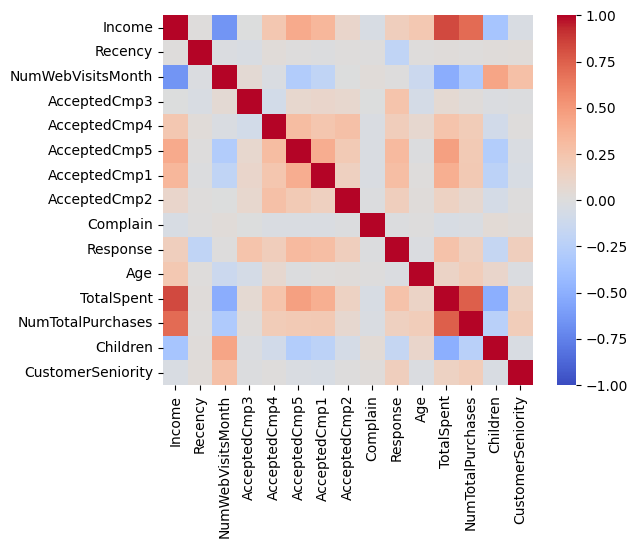

In [13]:
corr_mat = data_clean.corr(numeric_only=True)
corr_mat
sns.heatmap(corr_mat, square=True, vmin=-1, vmax=1, cmap='coolwarm')
pass

5. Обработка категориальных признаков

In [14]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder(drop='if_binary', sparse_output=False)
enc.fit(X_train[['Education', 'Marital_Status']])

OneHotEncoder(drop='if_binary', sparse_output=False)

In [15]:
dummies = pd.DataFrame(enc.transform(X_train[['Education', 'Marital_Status']]),
                       columns=enc.get_feature_names_out(), index=X_train.index)
dummies.head()

,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
1315,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2220,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
889,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
780,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2021,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [16]:
X_train = pd.concat((X_train, dummies), axis=1).drop(['Education', 'Marital_Status'], axis=1)

In [17]:
X_train.head()

,Income,Recency,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Age,...,Education_Master,Education_PhD,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
1315,27238.0,39,9,0,0,0,0,0,0,63,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2220,58025.0,81,4,0,0,0,0,0,0,46,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
889,68092.0,7,5,0,0,0,0,0,0,47,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
780,71466.0,86,1,0,0,0,0,0,0,51,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2021,43815.0,53,6,0,0,0,0,0,0,43,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


Масштабирование

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)

In [19]:
X_train.describe()

,Income,Recency,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Age,...,Education_Master,Education_PhD,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
count,1.680000e+03,1.680000e+03,1.680000e+03,1680.000000,1.680000e+03,1.680000e+03,1.680000e+03,1.680000e+03,1.680000e+03,1.680000e+03,...,1.680000e+03,1.680000e+03,1.680000e+03,1.680000e+03,1.680000e+03,1.680000e+03,1.680000e+03,1.680000e+03,1.680000e+03,1.680000e+03
mean,1.057355e-18,7.401487e-17,-1.818651e-16,0.000000,9.516197e-18,9.939139e-17,7.612958e-17,-1.691768e-17,5.286776e-18,-1.406282e-16,...,3.383537e-17,6.767074e-17,1.691768e-17,5.286776e-18,-2.537653e-17,2.960595e-17,-2.854859e-17,6.767074e-17,9.093255e-17,6.344132e-18
std,1.000298e+00,1.000298e+00,1.000298e+00,1.000298,1.000298e+00,1.000298e+00,1.000298e+00,1.000298e+00,1.000298e+00,1.000298e+00,...,1.000298e+00,1.000298e+00,1.000298e+00,1.000298e+00,1.000298e+00,1.000298e+00,1.000298e+00,1.000298e+00,1.000298e+00,1.000298e+00
min,-1.910391e+00,-1.695709e+00,-2.168479e+00,-0.282297,-2.735983e-01,-2.859671e-01,-2.608120e-01,-1.097643e-01,-1.011063e-01,-2.274543e+00,...,-4.346949e-01,-5.286895e-01,-2.440477e-02,-4.229549e-02,-3.355336e-01,-8.043997e-01,-5.176143e-01,-5.910986e-01,-1.822370e-01,-3.452383e-02
25%,-6.498861e-01,-8.589060e-01,-9.442003e-01,-0.282297,-2.735983e-01,-2.859671e-01,-2.608120e-01,-1.097643e-01,-1.011063e-01,-7.595171e-01,...,-4.346949e-01,-5.286895e-01,-2.440477e-02,-4.229549e-02,-3.355336e-01,-8.043997e-01,-5.176143e-01,-5.910986e-01,-1.822370e-01,-3.452383e-02
50%,-2.918128e-02,1.276374e-02,2.800779e-01,-0.282297,-2.735983e-01,-2.859671e-01,-2.608120e-01,-1.097643e-01,-1.011063e-01,-8.617212e-02,...,-4.346949e-01,-5.286895e-01,-2.440477e-02,-4.229549e-02,-3.355336e-01,-8.043997e-01,-5.176143e-01,-5.910986e-01,-1.822370e-01,-3.452383e-02
75%,5.996244e-01,8.495667e-01,6.881707e-01,-0.282297,-2.735983e-01,-2.859671e-01,-2.608120e-01,-1.097643e-01,-1.011063e-01,8.396772e-01,...,-4.346949e-01,-5.286895e-01,-2.440477e-02,-4.229549e-02,-3.355336e-01,1.243163e+00,-5.176143e-01,1.691765e+00,-1.822370e-01,-3.452383e-02
max,2.340808e+01,1.756103e+00,5.993376e+00,3.542370,3.654993e+00,3.496905e+00,3.834180e+00,9.110434e+00,9.890578e+00,5.889764e+00,...,2.300464e+00,1.891469e+00,4.097560e+01,2.364318e+01,2.980328e+00,1.243163e+00,1.931941e+00,1.691765e+00,5.487359e+00,2.896550e+01


7. Обучение и тест модели

In [20]:
X_test

,Education,Marital_Status,Income,Recency,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Age,TotalSpent,NumTotalPurchases,Children,CustomerSeniority
324,Graduation,Single,40464.0,78,8,0,0,0,0,0,0,72,630,24,1,10
96,Graduation,Widow,47916.0,72,6,0,1,0,0,0,0,65,606,22,1,11
2104,Basic,Married,14188.0,40,6,0,0,0,0,0,0,53,75,7,0,10
1259,Graduation,Together,76653.0,91,2,0,0,1,1,0,0,56,2279,23,0,10
1061,Graduation,Together,65196.0,34,5,1,0,0,0,0,0,67,1155,26,2,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2185,Graduation,Married,67716.0,8,5,0,1,0,0,0,0,65,1016,28,1,10
1995,2n Cycle,Married,96547.0,4,2,1,0,1,1,0,0,45,809,21,0,9
305,Master,Married,80950.0,44,2,0,0,0,1,0,0,64,1213,23,0,10
209,Graduation,Divorced,64497.0,17,8,1,0,0,0,0,0,71,1804,29,1,11


In [21]:
dummies = pd.DataFrame(enc.transform(X_test[['Education', 'Marital_Status']]),
                       columns=enc.get_feature_names_out(), index=X_test.index)
X_test = pd.concat((X_test, dummies), axis=1).drop(['Education', 'Marital_Status'], axis=1)

X_test = pd.DataFrame(scaler.transform(X_test),
                      columns=X_test.columns, index=X_test.index)
X_test

,Income,Recency,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Age,...,Education_Master,Education_PhD,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
324,-0.435534,1.023901,1.096263,-0.282297,-0.273598,-0.285967,-0.260812,-0.109764,-0.101106,1.344686,...,-0.434695,-0.528689,-0.024405,-0.042295,-0.335534,-0.804400,1.931941,-0.591099,-0.182237,-0.034524
96,-0.151788,0.814700,0.280078,-0.282297,3.654993,-0.285967,-0.260812,-0.109764,-0.101106,0.755509,...,-0.434695,-0.528689,-0.024405,-0.042295,-0.335534,-0.804400,-0.517614,-0.591099,5.487359,-0.034524
2104,-1.436034,-0.301037,0.280078,-0.282297,-0.273598,-0.285967,-0.260812,-0.109764,-0.101106,-0.254508,...,-0.434695,-0.528689,-0.024405,-0.042295,-0.335534,1.243163,-0.517614,-0.591099,-0.182237,-0.034524
1259,0.942418,1.477169,-1.352293,-0.282297,-0.273598,3.496905,3.834180,-0.109764,-0.101106,-0.002004,...,-0.434695,-0.528689,-0.024405,-0.042295,-0.335534,-0.804400,-0.517614,1.691765,-0.182237,-0.034524
1061,0.506175,-0.510238,-0.128015,3.542370,-0.273598,-0.285967,-0.260812,-0.109764,-0.101106,0.923845,...,-0.434695,-0.528689,-0.024405,-0.042295,-0.335534,-0.804400,-0.517614,1.691765,-0.182237,-0.034524
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2185,0.602128,-1.416775,-0.128015,-0.282297,3.654993,-0.285967,-0.260812,-0.109764,-0.101106,0.755509,...,-0.434695,-0.528689,-0.024405,-0.042295,-0.335534,1.243163,-0.517614,-0.591099,-0.182237,-0.034524
1995,1.699913,-1.556242,-1.352293,3.542370,-0.273598,3.496905,3.834180,-0.109764,-0.101106,-0.927853,...,-0.434695,-0.528689,-0.024405,-0.042295,-0.335534,1.243163,-0.517614,-0.591099,-0.182237,-0.034524
305,1.106033,-0.161570,-1.352293,-0.282297,-0.273598,-0.285967,3.834180,-0.109764,-0.101106,0.671341,...,2.300464,-0.528689,-0.024405,-0.042295,-0.335534,1.243163,-0.517614,-0.591099,-0.182237,-0.034524
209,0.479559,-1.102974,1.096263,3.542370,-0.273598,-0.285967,-0.260812,-0.109764,-0.101106,1.260518,...,-0.434695,-0.528689,-0.024405,-0.042295,2.980328,-0.804400,-0.517614,-0.591099,-0.182237,-0.034524


In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_table = pd.DataFrame(columns=['Train', 'Test'])
precision_table = pd.DataFrame(columns=['Train', 'Test'])
recall_table = pd.DataFrame(columns=['Train', 'Test'])
f1_table = pd.DataFrame(columns=['Train', 'Test'])

knn_classifier = KNeighborsClassifier(n_neighbors=7)
knn_classifier.fit(X_train, y_train)

y_train_pred = knn_classifier.predict(X_train)
y_test_pred = knn_classifier.predict(X_test)

accuracy_train = accuracy_score(y_train, y_train_pred)
accuracy_test = accuracy_score(y_test, y_test_pred)
precision_train = precision_score(y_train, y_train_pred)
precision_test = precision_score(y_test, y_test_pred)
recall_train = recall_score(y_train, y_train_pred)
recall_test = recall_score(y_test, y_test_pred)
f1_train = f1_score(y_train, y_train_pred)
f1_test = f1_score(y_test, y_test_pred)

accuracy_table.loc['k Nearest Neighbours', :] = (accuracy_train, accuracy_test)
precision_table.loc['k Nearest Neighbours', :] = (precision_train, precision_test)
recall_table.loc['k Nearest Neighbours', :] = (recall_train, recall_test)
f1_table.loc['k Nearest Neighbours', :] = (f1_train, f1_test)

print("Accuracy:")
print(accuracy_table)
print("\nPrecision:")
print(precision_table)
print("\nRecall:")
print(recall_table)
print("\nF1-Score:")
print(f1_table)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_test_pred)
print("\nМатрица ошибок:")
print(cm)

Accuracy:
                         Train      Test
k Nearest Neighbours  0.892857  0.857143

Precision:
                         Train   Test
k Nearest Neighbours  0.774194  0.575

Recall:
                         Train      Test
k Nearest Neighbours  0.387097  0.267442

F1-Score:
                         Train      Test
k Nearest Neighbours  0.516129  0.365079

Матрица ошибок:
[[457  17]
 [ 63  23]]


лучше предсказывает класс 0 (отказ), чем класс 1 (принятие)
63 реальных принятия предложения пропущены

In [23]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
import numpy as np

accuracy_table = pd.DataFrame(columns=['Train', 'Test'])
precision_table = pd.DataFrame(columns=['Train', 'Test'])
recall_table = pd.DataFrame(columns=['Train', 'Test'])
f1_table = pd.DataFrame(columns=['Train', 'Test'])

k_range = range(1, 21)
train_scores = []
test_scores = []
best_k = 1
best_score = 0

print("Подбор оптимального k для KNN:")
print("k\tTrain F1\tTest F1")
print("-" * 30)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)

    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)

    train_scores.append(train_f1)
    test_scores.append(test_f1)

    print(f"{k}\t{train_f1:.4f}\t\t{test_f1:.4f}")

    if test_f1 > best_score:
        best_score = test_f1
        best_k = k

print(f"\nОптимальное количество соседей: k = {best_k}")
print(f"Лучший F1-score на тесте: {best_score:.4f}")

Подбор оптимального k для KNN:
k	Train F1	Test F1
------------------------------
1	0.9818		0.4141
2	0.5909		0.3538
3	0.6651		0.4231
4	0.5084		0.3443
5	0.5692		0.3939
6	0.4740		0.3770
7	0.5161		0.3651
8	0.4000		0.3130
9	0.4425		0.3415
10	0.3964		0.3333
11	0.4348		0.3500
12	0.3904		0.2679
13	0.4393		0.3025
14	0.3914		0.2727
15	0.4235		0.2883
16	0.4096		0.2727
17	0.4198		0.2982
18	0.4251		0.2883
19	0.4201		0.3036
20	0.3976		0.2778

Оптимальное количество соседей: k = 3
Лучший F1-score на тесте: 0.4231


In [24]:
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train, y_train)

y_train_pred_final = final_knn.predict(X_train)
y_test_pred_final = final_knn.predict(X_test)

accuracy_train = accuracy_score(y_train, y_train_pred_final)
accuracy_test = accuracy_score(y_test, y_test_pred_final)
precision_train = precision_score(y_train, y_train_pred_final)
precision_test = precision_score(y_test, y_test_pred_final)
recall_train = recall_score(y_train, y_train_pred_final)
recall_test = recall_score(y_test, y_test_pred_final)
f1_train = f1_score(y_train, y_train_pred_final)
f1_test = f1_score(y_test, y_test_pred_final)

accuracy_table.loc[f'KNN (k={best_k})', :] = (accuracy_train, accuracy_test)
precision_table.loc[f'KNN (k={best_k})', :] = (precision_train, precision_test)
recall_table.loc[f'KNN (k={best_k})', :] = (recall_train, recall_test)
f1_table.loc[f'KNN (k={best_k})', :] = (f1_train, f1_test)

print("\nAccuracy:")
print(accuracy_table)
print("\nPrecision:")
print(precision_table)
print("\nRecall:")
print(recall_table)
print("\nF1-Score:")
print(f1_table)

from sklearn.metrics import confusion_matrix
cm_final = confusion_matrix(y_test, y_test_pred_final)
print("\nМатрица ошибок финальной модели:")
print(cm_final)


Accuracy:
              Train      Test
KNN (k=3)  0.915476  0.839286

Precision:
              Train      Test
KNN (k=3)  0.801136  0.471429

Recall:
              Train      Test
KNN (k=3)  0.568548  0.383721

F1-Score:
              Train      Test
KNN (k=3)  0.665094  0.423077

Матрица ошибок финальной модели:
[[437  37]
 [ 53  33]]


результаты относительно лучше, но всё равно много ошибок для класса "1".

**Общие выводы**:
Хоть и был выбран оптимальный параметр, получилось низкое качество предсказания положительного класса и высокий процент пропущенных целевых клиентов. Необходима доработка.

***ДЗ на 20 декабря***

Стандартизация данных

In [25]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from scipy.stats import mode
import warnings
warnings.filterwarnings('ignore')

clustering_data = data_clean.copy()

true_labels = clustering_data['Response'].copy()
clustering_data = clustering_data.drop(['Response'], axis=1)

label_encoders = {}
for column in ['Education', 'Marital_Status']:
    le = LabelEncoder()
    clustering_data[column] = le.fit_transform(clustering_data[column].astype(str))
    label_encoders[column] = le

print("Размер данных для кластеризации:", clustering_data.shape)
print("\nПервые 5 строк данных для кластеризации:")
print(clustering_data.head())
print("\nИстинные метки (Response):")
print(true_labels.value_counts())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(clustering_data)

Размер данных для кластеризации: (2195, 16)

Первые 5 строк данных для кластеризации:
   Education  Marital_Status   Income  Recency  NumWebVisitsMonth  \
0          2               4  58138.0       58                  7   
1          2               4  46344.0       38                  5   
2          2               5  71613.0       26                  4   
3          2               5  26646.0       26                  6   
4          4               3  58293.0       94                  5   

   AcceptedCmp3  AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  \
0             0             0             0             0             0   
1             0             0             0             0             0   
2             0             0             0             0             0   
3             0             0             0             0             0   
4             0             0             0             0             0   

   Complain  Age  TotalSpent  NumTotalPurchases 

Понижение размерности

Объясненная дисперсия компонентами PCA: [0.23633475 0.0883073 ]
Суммарная объясненная дисперсия: 0.325


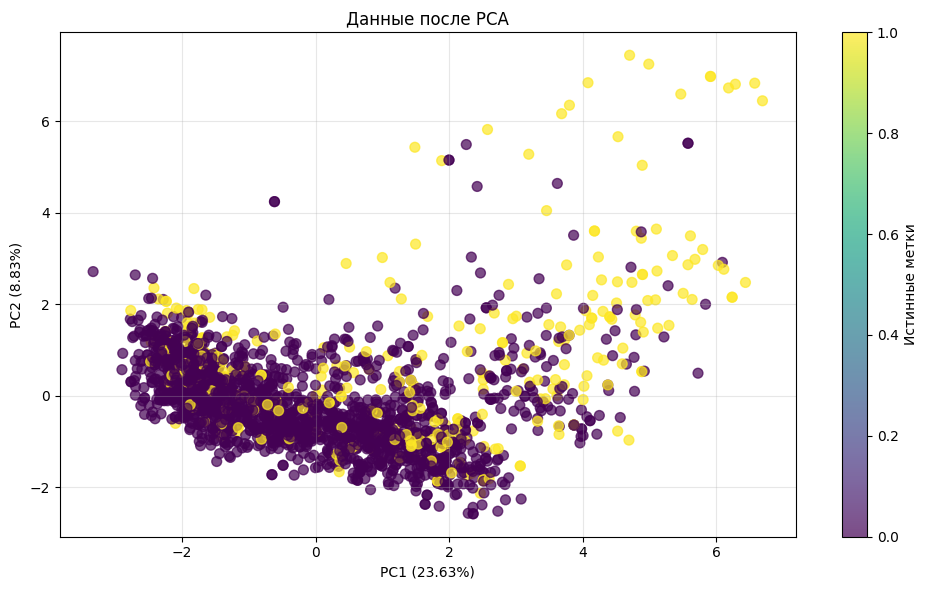

In [27]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Объясненная дисперсия компонентами PCA: {pca.explained_variance_ratio_}")
print(f"Суммарная объясненная дисперсия: {sum(pca.explained_variance_ratio_):.3f}")

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=true_labels,
                      cmap='viridis', alpha=0.7, s=50)
plt.colorbar(scatter, label='Истинные метки')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.title('Данные после PCA')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

КЛАСТЕРИЗАЦИЯ

K-Means

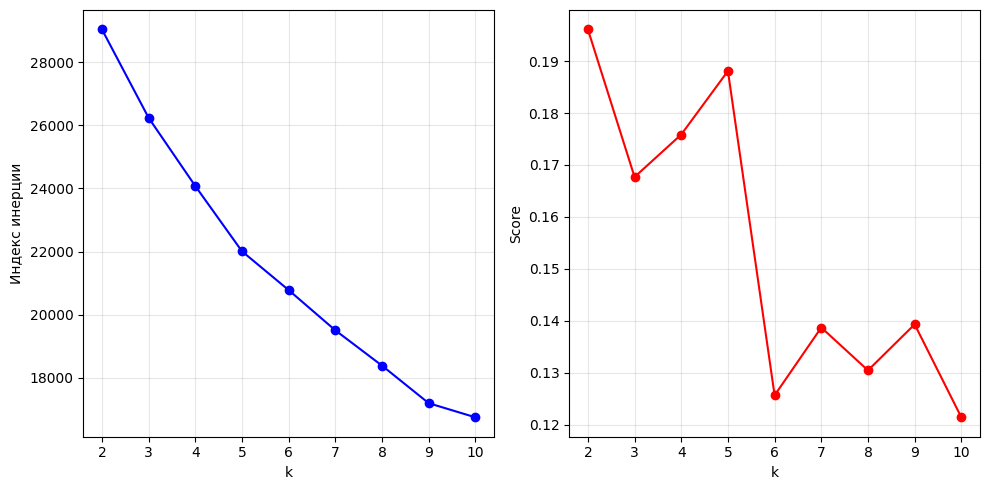

Оптимальное количество кластеров: 2

Распределение кластеров K-Means:
Кластер 0: 1258 объектов (57.3%)
Кластер 1: 937 объектов (42.7%)


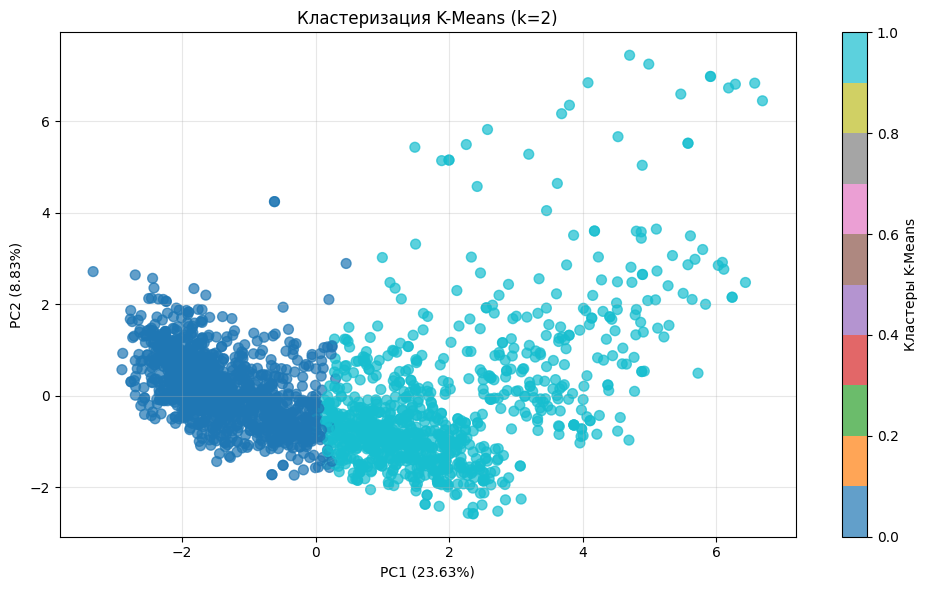

In [29]:
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('k')
plt.ylabel('Индекс инерции')
plt.grid(True, alpha=0.3)

silhouette_scores = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, cluster_labels))

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, 'ro-')
plt.xlabel('k')
plt.ylabel('Score')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"Оптимальное количество кластеров: {optimal_k}")

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

print(f"\nРаспределение кластеров K-Means:")
unique, counts = np.unique(kmeans_labels, return_counts=True)
for label, count in zip(unique, counts):
    print(f"Кластер {label}: {count} объектов ({count/len(kmeans_labels):.1%})")

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels,
                      cmap='tab10', alpha=0.7, s=50)
plt.colorbar(scatter, label='Кластеры K-Means')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.title(f'Кластеризация K-Means (k={optimal_k})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

DBSCAN

eps = 6.94
min_samples = 10

Результаты DBSCAN:
Количество кластеров: 3
Количество шумовых точек: 1 (0.0%)

Распределение по кластерам:
  Кластер 0: 2149 объектов (97.9%)
  Кластер 1: 18 объектов (0.8%)
  Кластер 2: 27 объектов (1.2%)


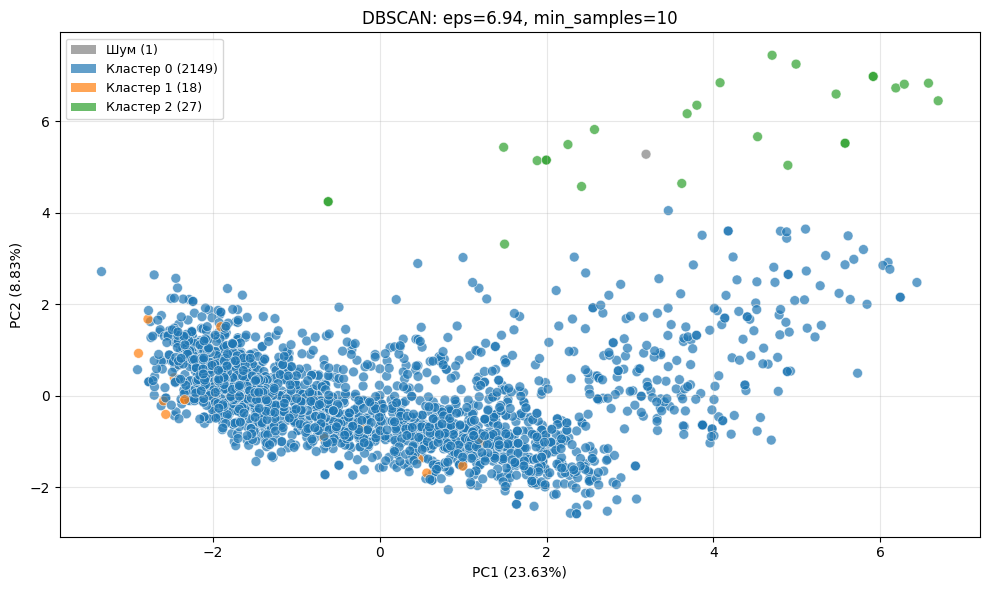

Сравнение с истинными метками
Точность: 0.8564

Матрица ошибок:
[[1861    9]
 [ 306   18]]


In [35]:
eps_optimal = 6.94
min_samples = 10

print(f"eps = {eps_optimal}")
print(f"min_samples = {min_samples}")

dbscan = DBSCAN(eps=eps_optimal, min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"\nРезультаты DBSCAN:")
print(f"Количество кластеров: {n_clusters}")
print(f"Количество шумовых точек: {n_noise} ({n_noise/len(dbscan_labels):.1%})")

if n_clusters > 0:
    print("\nРаспределение по кластерам:")
    unique, counts = np.unique(dbscan_labels[dbscan_labels != -1], return_counts=True)
    total_clustered = len(dbscan_labels) - n_noise
    for label, count in zip(unique, counts):
        print(f"  Кластер {label}: {count} объектов ({count/total_clustered:.1%})")

plt.figure(figsize=(10, 6))

colors = ['gray' if label == -1 else plt.cm.tab10(label % 10)
          for label in dbscan_labels]

scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.7, s=50,
                      edgecolors='w', linewidth=0.5)

from matplotlib.patches import Patch
legend_elements = []
if -1 in dbscan_labels and n_noise > 0:
    legend_elements.append(Patch(facecolor='gray', alpha=0.7, label=f'Шум ({n_noise})'))

for label in sorted(set(dbscan_labels)):
    if label != -1:
        count = list(dbscan_labels).count(label)
        legend_elements.append(Patch(facecolor=plt.cm.tab10(label % 10),
                                   alpha=0.7, label=f'Кластер {label} ({count})'))

if legend_elements:
    plt.legend(handles=legend_elements, loc='best', fontsize=9)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.title(f'DBSCAN: eps={eps_optimal}, min_samples={min_samples}')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Сравнение с истинными метками")

if n_clusters > 0:
    matched_labels_dbscan = np.zeros_like(dbscan_labels)

    for cluster in set(dbscan_labels):
        if cluster != -1:
            mask = dbscan_labels == cluster
            if sum(mask) > 0:
                most_common = mode(true_labels[mask])[0]
                matched_labels_dbscan[mask] = most_common

    if n_noise > 0:
        non_noise_mask = dbscan_labels != -1
        if sum(non_noise_mask) > 0:
            true_labels_filtered = true_labels[non_noise_mask]
            matched_filtered = matched_labels_dbscan[non_noise_mask]
    else:
        non_noise_mask = np.ones_like(dbscan_labels, dtype=bool)
        true_labels_filtered = true_labels
        matched_filtered = matched_labels_dbscan

    adj_rand = adjusted_rand_score(true_labels_filtered, matched_filtered)
    nmi = normalized_mutual_info_score(true_labels_filtered, matched_filtered)
    accuracy = np.mean(true_labels_filtered == matched_filtered)

    print(f"Точность: {accuracy:.4f}")

    # Матрица ошибок
    cm = confusion_matrix(true_labels_filtered, matched_filtered)
    print(f"\nМатрица ошибок:")
    print(cm)

Иерархия


Распределение кластеров агломеративной кластеризации:
Кластер 0: 960 объектов (43.7%)
Кластер 1: 1235 объектов (56.3%)


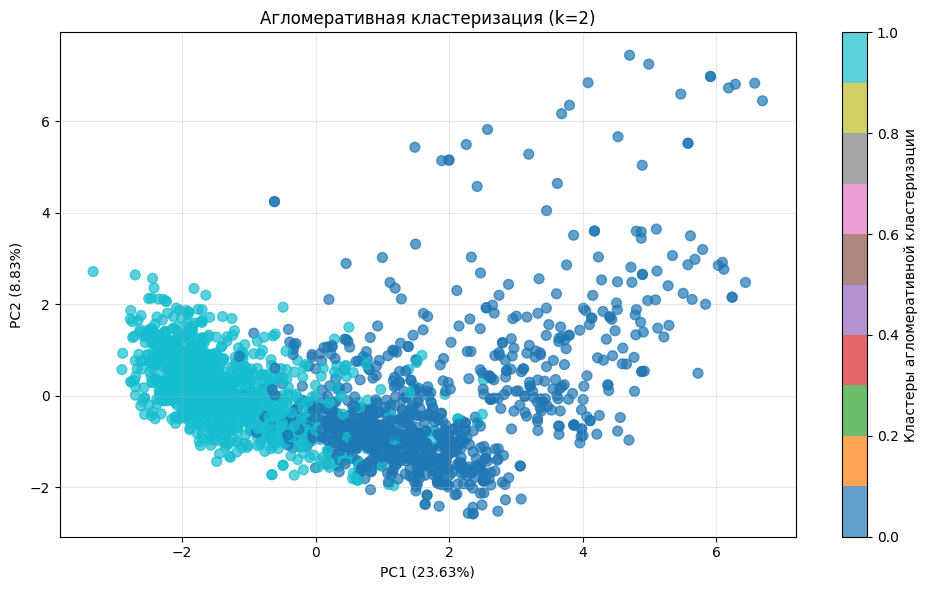

In [36]:
agg_clustering = AgglomerativeClustering(n_clusters=optimal_k)
agg_labels = agg_clustering.fit_predict(X_scaled)

print(f"\nРаспределение кластеров агломеративной кластеризации:")
unique, counts = np.unique(agg_labels, return_counts=True)
for label, count in zip(unique, counts):
    print(f"Кластер {label}: {count} объектов ({count/len(agg_labels):.1%})")

# Визуализация кластеров агломеративной кластеризации
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels,
                      cmap='tab10', alpha=0.7, s=50)
plt.colorbar(scatter, label='Кластеры агломеративной кластеризации')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.title(f'Агломеративная кластеризация (k={optimal_k})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Сравнение по метрикам

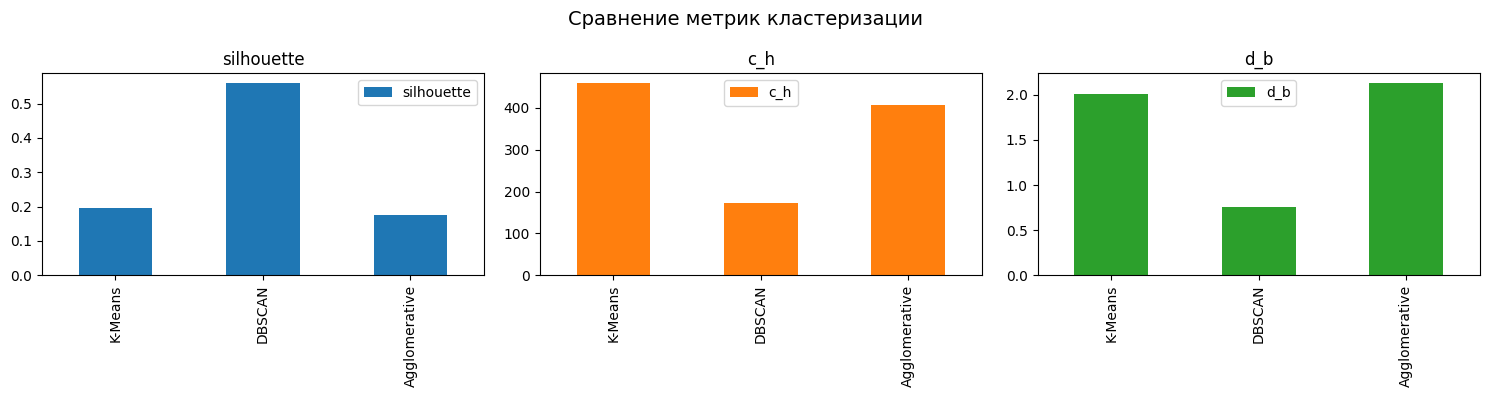

In [40]:
# Функция для вычисления метрик кластеризации
def evaluate_clustering(X, labels, method_name):
    # Игнорируем шумовые точки для DBSCAN
    if method_name == "DBSCAN" and -1 in labels:
        mask = labels != -1
        if sum(mask) > 1 and len(set(labels[mask])) > 1:
            X_eval = X[mask]
            labels_eval = labels[mask]
        else:
            return None
    else:
        X_eval = X
        labels_eval = labels

    # Проверяем, есть ли достаточно кластеров
    if len(set(labels_eval)) < 2:
        return None

    metrics = {}
    try:
        metrics['silhouette'] = silhouette_score(X_eval, labels_eval)
    except:
        metrics['silhouette'] = np.nan

    try:
        metrics['c_h'] = calinski_harabasz_score(X_eval, labels_eval)
    except:
        metrics['c_h'] = np.nan

    try:
        metrics['d_b'] = davies_bouldin_score(X_eval, labels_eval)
    except:
        metrics['d_b'] = np.nan

    return metrics

# Вычисляем метрики для каждого метода
metrics_results = {}
methods = {
    'K-Means': kmeans_labels,
    'DBSCAN': dbscan_labels,
    'Agglomerative': agg_labels
}

for method_name, labels in methods.items():
    metrics = evaluate_clustering(X_scaled, labels, method_name)
    if metrics:
        metrics_results[method_name] = metrics

# Визуализация сравнения метрик
if metrics_results:
    metrics_df = pd.DataFrame(metrics_results).T
    metrics_df.plot(kind='bar', subplots=True, layout=(1, 3),
                   figsize=(15, 4), legend=True, sharey=False)
    plt.suptitle('Сравнение метрик кластеризации', fontsize=14)
    plt.tight_layout()
    plt.show()

Сравнение с истинными метками


Сравнение с истинными метками (0 - не принял, 1 - принял):

K-Means:
  Adjusted Rand Index: 0.0000
  Normalized Mutual Information: 0.0000
  Точность (accuracy): 0.8519
  Матрица ошибок:
[[1870    0]
 [ 325    0]]

DBSCAN:
  Adjusted Rand Index: 0.0678
  Normalized Mutual Information: 0.0358
  Точность (accuracy): 0.8564
  Матрица ошибок:
[[1861    9]
 [ 306   18]]

Агломеративная:
  Adjusted Rand Index: 0.0000
  Normalized Mutual Information: 0.0000
  Точность (accuracy): 0.8519
  Матрица ошибок:
[[1870    0]
 [ 325    0]]


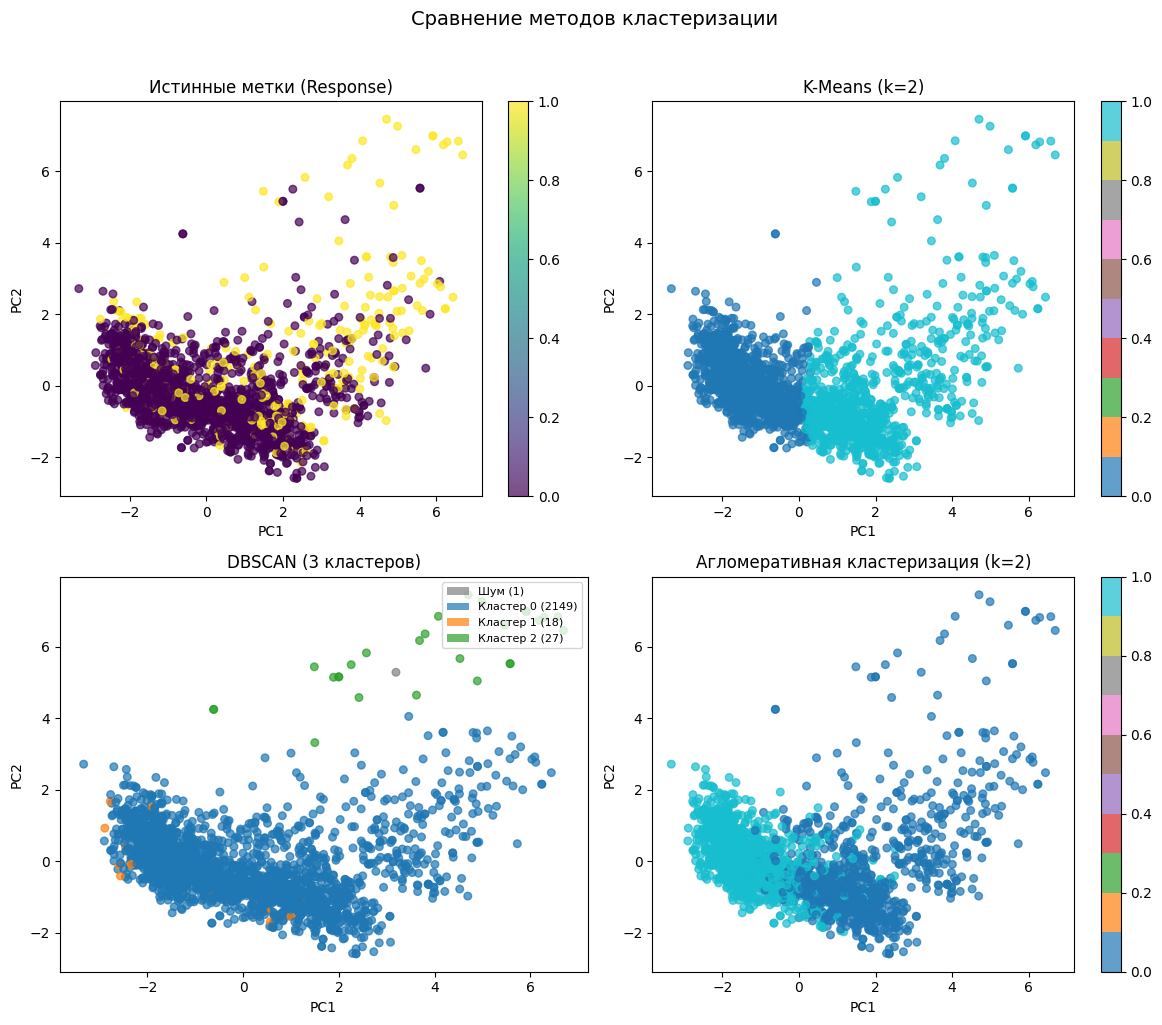

In [45]:
def match_labels(cluster_labels, true_labels):
    matched_labels = np.zeros_like(cluster_labels)

    for cluster in set(cluster_labels):
        if cluster != -1:
            mask = cluster_labels == cluster
            if sum(mask) > 0:
                most_common = mode(true_labels[mask])[0]
                matched_labels[mask] = most_common

    return matched_labels

matched_labels_kmeans = match_labels(kmeans_labels, true_labels)
matched_labels_agg = match_labels(agg_labels, true_labels)

dbscan_non_noise_mask = dbscan_labels != -1
if sum(dbscan_non_noise_mask) > 0:
    matched_labels_dbscan = np.full_like(dbscan_labels, -1)
    temp_matched = match_labels(dbscan_labels[dbscan_non_noise_mask],
                               true_labels[dbscan_non_noise_mask])
    matched_labels_dbscan[dbscan_non_noise_mask] = temp_matched
else:
    matched_labels_dbscan = np.full_like(dbscan_labels, -1)

def compare_with_true(pred_labels, true_labels, method_name):
    mask = pred_labels != -1
    if sum(mask) == 0:
        print(f"\n{method_name}: Нет точек для сравнения")
        return

    adj_rand = adjusted_rand_score(true_labels[mask], pred_labels[mask])
    nmi = normalized_mutual_info_score(true_labels[mask], pred_labels[mask])

    accuracy = np.mean(true_labels[mask] == pred_labels[mask])

    print(f"\n{method_name}:")
    print(f"  Adjusted Rand Index: {adj_rand:.4f}")
    print(f"  Normalized Mutual Information: {nmi:.4f}")
    print(f"  Точность (accuracy): {accuracy:.4f}")

    cm = confusion_matrix(true_labels[mask], pred_labels[mask])
    print(f"  Матрица ошибок:\n{cm}")

    return adj_rand, nmi, accuracy

print("\nСравнение с истинными метками (0 - не принял, 1 - принял):")
compare_with_true(matched_labels_kmeans, true_labels, "K-Means")
compare_with_true(matched_labels_dbscan, true_labels, "DBSCAN")
compare_with_true(matched_labels_agg, true_labels, "Агломеративная")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

scatter1 = axes[0, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=true_labels,
                              cmap='viridis', alpha=0.7, s=30)
axes[0, 0].set_title('Истинные метки (Response)')
axes[0, 0].set_xlabel('PC1')
axes[0, 0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0, 0])

scatter2 = axes[0, 1].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels,
                              cmap='tab10', alpha=0.7, s=30)
axes[0, 1].set_title(f'K-Means (k={optimal_k})')
axes[0, 1].set_xlabel('PC1')
axes[0, 1].set_ylabel('PC2')
plt.colorbar(scatter2, ax=axes[0, 1])

colors_dbscan = ['gray' if label == -1 else plt.cm.tab10(label % 10) for label in dbscan_labels]
scatter3 = axes[1, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=colors_dbscan,
                              alpha=0.7, s=30)
axes[1, 0].set_title(f'DBSCAN ({n_clusters} кластеров)')
axes[1, 0].set_xlabel('PC1')
axes[1, 0].set_ylabel('PC2')

from matplotlib.patches import Patch
if n_clusters > 0:
    legend_elements = []
    if -1 in dbscan_labels:
        noise_count = list(dbscan_labels).count(-1)
        if noise_count > 0:
            legend_elements.append(Patch(facecolor='gray', alpha=0.7, label=f'Шум ({noise_count})'))

    for cluster in sorted(set(dbscan_labels)):
        if cluster != -1:
            count = list(dbscan_labels).count(cluster)
            legend_elements.append(Patch(facecolor=plt.cm.tab10(cluster % 10),
                                       alpha=0.7, label=f'Кластер {cluster} ({count})'))

    if legend_elements:
        axes[1, 0].legend(handles=legend_elements, loc='upper right', fontsize=8)

scatter4 = axes[1, 1].scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels,
                              cmap='tab10', alpha=0.7, s=30)
axes[1, 1].set_title(f'Агломеративная кластеризация (k={optimal_k})')
axes[1, 1].set_xlabel('PC1')
axes[1, 1].set_ylabel('PC2')
plt.colorbar(scatter4, ax=axes[1, 1])

plt.suptitle('Сравнение методов кластеризации', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Выводы: Все три метода кластеризации показали низкое соответствие с истинными метками. DBSCAN показал немного лучшие результаты, предсказав 18 точек как класс 1, но все равно дал очень низкие метрики. Данные плохо поддаются кластеризации. Все методы в основном предсказывают мажоритарный класс 0, что дает высокую точность из-за несбалансированности данных.